In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from collections import Counter
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

c:\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.20.0
GPU available: False


In [2]:
with open("data_splits.pkl", "rb") as f:
    train, val, test, vocab = pickle.load(f)

print(f"Train sentences: {len(train)}")
print(f"Val sentences: {len(val)}")
print(f"Test sentences: {len(test)}")
print(f"Vocabulary size: {len(vocab)}")

Train sentences: 5567
Val sentences: 696
Test sentences: 696
Vocabulary size: 3948


In [3]:
word2idx = {word: idx for idx, word in enumerate(sorted(vocab))}
idx2word = {idx: word for word, idx in word2idx.items()}

vocab_size = len(word2idx)
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 3948


In [4]:
def create_sequences(sentences, word2idx, seq_len=20):
    """Create input-output sequences for language modeling"""
    X, y = [], []
    
    for sentence in sentences:
        # Convert to indices
        indices = [word2idx[w] for w in sentence]
        
        # Create overlapping sequences
        for i in range(len(indices) - seq_len):
            X.append(indices[i:i+seq_len])
            y.append(indices[i+1:i+seq_len+1])
    
    return np.array(X), np.array(y)

In [5]:
SEQ_LEN = 20
BATCH_SIZE = 64

print("Creating sequences...")
X_train, y_train = create_sequences(train, word2idx, SEQ_LEN)
X_val, y_val = create_sequences(val, word2idx, SEQ_LEN)
X_test, y_test = create_sequences(test, word2idx, SEQ_LEN)

print(f"Train sequences: {len(X_train)}")
print(f"Val sequences: {len(X_val)}")
print(f"Test sequences: {len(X_test)}")
print(f"Input shape: {X_train.shape}")
print(f"Output shape: {y_train.shape}")

Creating sequences...
Train sequences: 31369
Val sequences: 3644
Test sequences: 4011
Input shape: (31369, 20)
Output shape: (31369, 20)


In [6]:
class RecurrentLM(keras.Model):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=2, dropout=0.3, weight_tying=True):
        super(RecurrentLM, self).__init__()
        
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.weight_tying = weight_tying
        
        # Embedding layer
        self.embedding = layers.Embedding(vocab_size, embed_dim)
        
        # LSTM layers
        if num_layers == 1:
            self.lstm = layers.LSTM(hidden_dim, return_sequences=True, dropout=dropout)
        else:
            self.lstm = layers.LSTM(hidden_dim, return_sequences=True, dropout=dropout)
            self.lstm2 = layers.LSTM(hidden_dim, return_sequences=True, dropout=dropout)
        
        self.num_layers = num_layers
        self.dropout_layer = layers.Dropout(dropout)
        
        # Output layer
        if weight_tying and embed_dim == hidden_dim:
            # We'll tie weights manually after building
            self.output_layer = layers.Dense(vocab_size, use_bias=True)
            self.projection = None
            print("Weight tying enabled (will tie after build)")
        elif weight_tying:
            # Need projection layer
            self.projection = layers.Dense(embed_dim)
            self.output_layer = layers.Dense(vocab_size, use_bias=True)
            print(f"Weight tying with projection: {hidden_dim} -> {embed_dim}")
        else:
            self.output_layer = layers.Dense(vocab_size)
            self.projection = None
    
    def call(self, x, training=False):
        # x: (batch, seq_len)
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)
        
        # LSTM layers
        if self.num_layers == 1:
            lstm_out = self.lstm(embedded, training=training)
        else:
            lstm_out = self.lstm(embedded, training=training)
            lstm_out = self.lstm2(lstm_out, training=training)
        
        lstm_out = self.dropout_layer(lstm_out, training=training)
        
        # Projection if needed for weight tying
        if self.projection is not None:
            lstm_out = self.projection(lstm_out)
        
        # Output
        logits = self.output_layer(lstm_out)  # (batch, seq_len, vocab_size)
        return logits
    
    def tie_weights(self):
        """Tie embedding and output layer weights"""
        if self.weight_tying:
            # Transpose embedding weights and assign to output layer
            self.output_layer.kernel.assign(tf.transpose(self.embedding.embeddings))
            print("Weights tied successfully!")

# Build and compile RNN model
print("=" * 50)
print("Building Recurrent LM (LSTM with Weight Tying)")
print("=" * 50)

rnn_model = RecurrentLM(vocab_size, embed_dim=256, hidden_dim=256, 
                        num_layers=2, dropout=0.3, weight_tying=True)

# Build the model
rnn_model.build(input_shape=(None, SEQ_LEN))

# Tie weights after building
rnn_model.tie_weights()

rnn_model.summary()

Building Recurrent LM (LSTM with Weight Tying)
Weight tying enabled (will tie after build)


c:\Python312\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'recurrent_lm', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


AttributeError: You must build the layer before accessing `kernel`.

In [7]:
def build_cnn_lm(vocab_size, embed_dim=128, num_filters=256, kernel_sizes=[3, 5, 7], dropout=0.3):
    """Build Convolutional Language Model"""
    
    inputs = layers.Input(shape=(SEQ_LEN,))
    
    # Embedding
    x = layers.Embedding(vocab_size, embed_dim)(inputs)
    
    # Multiple CNN branches with different kernel sizes
    conv_outputs = []
    for kernel_size in kernel_sizes:
        conv = layers.Conv1D(num_filters, kernel_size, padding='same', activation='relu')(x)
        conv_outputs.append(conv)
    
    # Concatenate all conv outputs
    if len(conv_outputs) > 1:
        combined = layers.Concatenate()(conv_outputs)
    else:
        combined = conv_outputs[0]
    
    # Dropout
    combined = layers.Dropout(dropout)(combined)
    
    # Output layer
    outputs = layers.Dense(vocab_size)(combined)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

print("=" * 50)
print("Building Convolutional LM")
print("=" * 50)

cnn_model = build_cnn_lm(vocab_size, embed_dim=128, num_filters=256, 
                         kernel_sizes=[3, 5, 7], dropout=0.3)

cnn_model.summary()

Building Convolutional LM


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 20, 128)   │    505,344 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 20, 256)   │     98,560 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 20, 256)   │    164,096 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 20, 256)   │    229,632 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 20, 768)   │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0],   │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 20, 768)   │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 20, 3948)  │  3,036,012 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,033,644 (15.39 MB)

 Trainable params: 4,033,644 (15.39 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Custom loss function (sparse categorical crossentropy)
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Compile RNN model
rnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_fn,
    metrics=['accuracy']
)

# Compile CNN model
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_fn,
    metrics=['accuracy']
)

print("Models compiled successfully!")

Models compiled successfully!


In [9]:
class PerplexityCallback(keras.callbacks.Callback):
    """Calculate perplexity during training"""
    def __init__(self, validation_data):
        super().__init__()
        self.validation_data = validation_data
        self.perplexities = []
    
    def on_epoch_end(self, epoch, logs=None):
        X_val, y_val = self.validation_data
        
        # Predict
        y_pred = self.model.predict(X_val, verbose=0)
        
        # Calculate cross-entropy loss
        loss = tf.keras.losses.sparse_categorical_crossentropy(
            y_val, y_pred, from_logits=True
        )
        
        # Calculate perplexity
        perplexity = tf.exp(tf.reduce_mean(loss)).numpy()
        self.perplexities.append(perplexity)
        
        print(f" - val_perplexity: {perplexity:.2f}")

In [12]:
print("=" * 50)
print("Training Recurrent LM (LSTM with Weight Tying)")
print("=" * 50)

# Callbacks
rnn_perplexity_callback = PerplexityCallback((X_val, y_val))
rnn_early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# Train
rnn_history = rnn_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=5,
    validation_data=(X_val, y_val),
    callbacks=[rnn_perplexity_callback, rnn_early_stopping],
    verbose=1
)

# Save model
rnn_model.save_weights('rnn_lm_weights.weights.h5')
print("\nRNN model weights saved!")

Training Recurrent LM (LSTM with Weight Tying)
Epoch 1/5
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.1671 - loss: 4.6690 - val_perplexity: 223.63
491/491 ━━━━━━━━━━━━━━━━━━━━ 63s 129ms/step - accuracy: 0.1695 - loss: 4.6414 - val_accuracy: 0.1336 - val_loss: 5.4100
Epoch 2/5
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.1735 - loss: 4.5508 - val_perplexity: 231.88
491/491 ━━━━━━━━━━━━━━━━━━━━ 63s 128ms/step - accuracy: 0.1760 - loss: 4.5211 - val_accuracy: 0.1373 - val_loss: 5.4462
Epoch 3/5
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.1804 - loss: 4.4375 - val_perplexity: 242.51
491/491 ━━━━━━━━━━━━━━━━━━━━ 64s 130ms/step - accuracy: 0.1837 - loss: 4.4077 - val_accuracy: 0.1379 - val_loss: 5.4911
Epoch 4/5
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.1891 - loss: 4.3299 - val_perplexity: 253.77
491/491 ━━━━━━━━━━━━━━━━━━━━ 62s 126ms/step - accuracy: 0.1922 - loss: 4.3009 - val_accuracy: 0.1384 - val_loss: 5.5364
Epoch 5/5
490/491 ━━━━━━━

In [13]:
def calculate_perplexity(model, X, y):
    """Calculate perplexity for a dataset"""
    y_pred = model.predict(X, verbose=0)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y, y_pred, from_logits=True)
    perplexity = tf.exp(tf.reduce_mean(loss)).numpy()
    return perplexity

rnn_test_ppl = calculate_perplexity(rnn_model, X_test, y_test)
print(f"\nRecurrent LM Test Perplexity: {rnn_test_ppl:.2f}")


Recurrent LM Test Perplexity: 232.59


In [16]:
print("=" * 50)
print("Training Convolutional LM")
print("=" * 50)

# Callbacks
cnn_perplexity_callback = PerplexityCallback((X_val, y_val))
cnn_early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# Train
cnn_history = cnn_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=5,
    validation_data=(X_val, y_val),
    callbacks=[cnn_perplexity_callback, cnn_early_stopping],
    verbose=1
)

# Save model
cnn_model.save_weights('cnn_lm_weights.weights.h5')
print("\nCNN model weights saved!")

Training Convolutional LM
Epoch 1/5
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9595 - loss: 0.1981 - val_perplexity: 2.60
491/491 ━━━━━━━━━━━━━━━━━━━━ 93s 190ms/step - accuracy: 0.9601 - loss: 0.1928 - val_accuracy: 0.8888 - val_loss: 0.9555
Epoch 2/5
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9621 - loss: 0.1754 - val_perplexity: 2.62
491/491 ━━━━━━━━━━━━━━━━━━━━ 93s 190ms/step - accuracy: 0.9628 - loss: 0.1704 - val_accuracy: 0.8900 - val_loss: 0.9638
Epoch 3/5
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9650 - loss: 0.1553 - val_perplexity: 2.66
491/491 ━━━━━━━━━━━━━━━━━━━━ 96s 195ms/step - accuracy: 0.9657 - loss: 0.1507 - val_accuracy: 0.8914 - val_loss: 0.9771
Epoch 4/5
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9680 - loss: 0.1374 - val_perplexity: 2.68
491/491 ━━━━━━━━━━━━━━━━━━━━ 95s 193ms/step - accuracy: 0.9687 - loss: 0.1325 - val_accuracy: 0.8901 - val_loss: 0.9858
Epoch 5/5
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step -

In [17]:
cnn_test_ppl = calculate_perplexity(cnn_model, X_test, y_test)
print(f"\nConvolutional LM Test Perplexity: {cnn_test_ppl:.2f}")


Convolutional LM Test Perplexity: 2.47


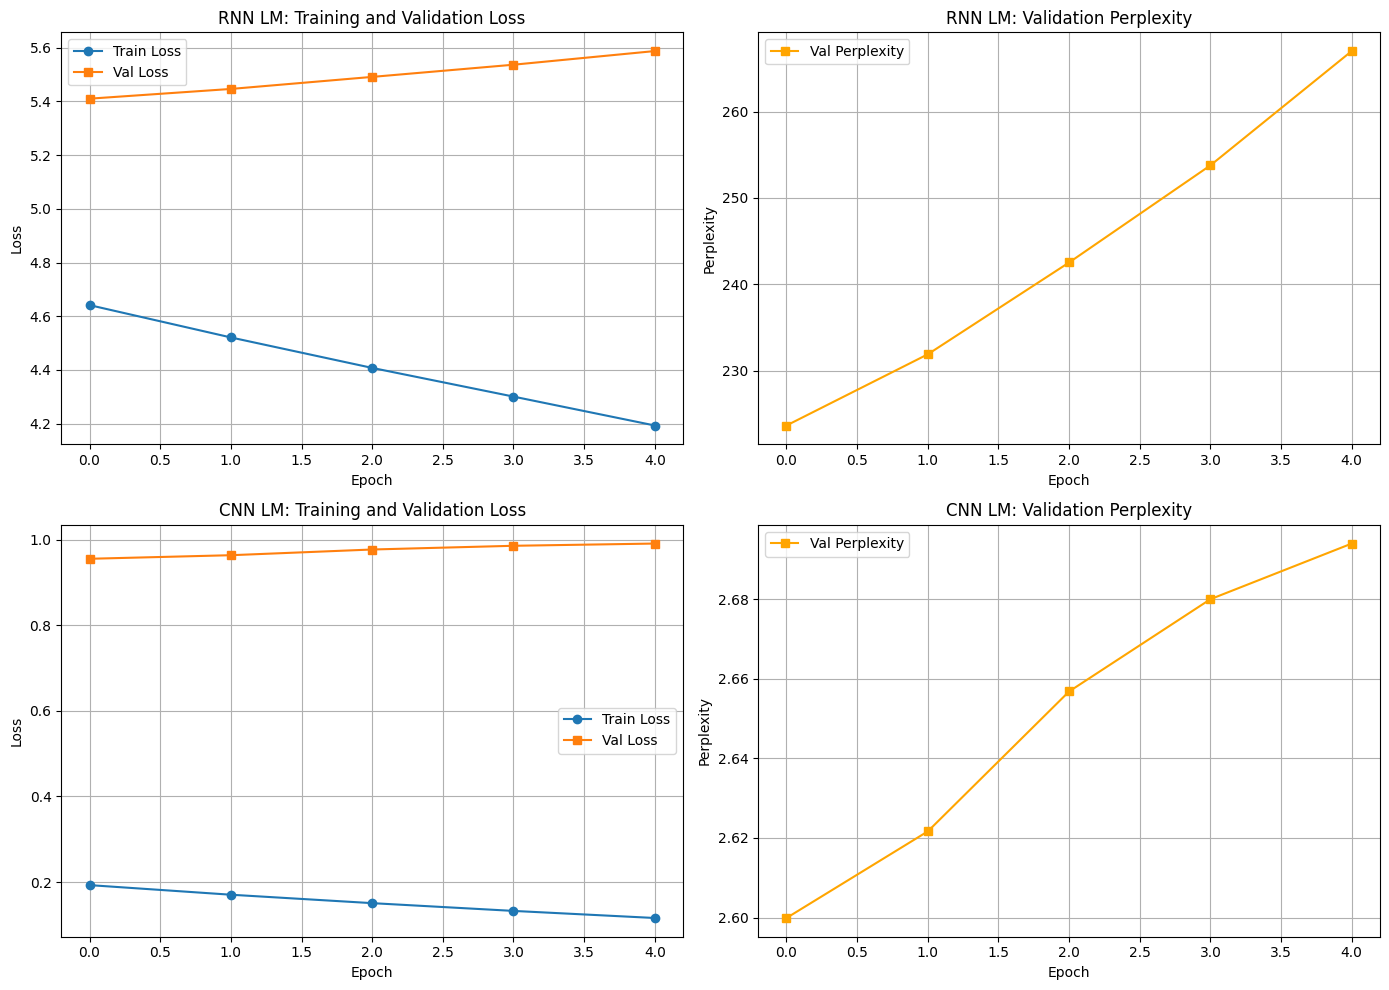

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# RNN Loss
axes[0, 0].plot(rnn_history.history['loss'], label='Train Loss', marker='o')
axes[0, 0].plot(rnn_history.history['val_loss'], label='Val Loss', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('RNN LM: Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# RNN Perplexity
axes[0, 1].plot(rnn_perplexity_callback.perplexities, 
                label='Val Perplexity', marker='s', color='orange')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Perplexity')
axes[0, 1].set_title('RNN LM: Validation Perplexity')
axes[0, 1].legend()
axes[0, 1].grid(True)

# CNN Loss
axes[1, 0].plot(cnn_history.history['loss'], label='Train Loss', marker='o')
axes[1, 0].plot(cnn_history.history['val_loss'], label='Val Loss', marker='s')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('CNN LM: Training and Validation Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# CNN Perplexity
axes[1, 1].plot(cnn_perplexity_callback.perplexities, 
                label='Val Perplexity', marker='s', color='orange')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Perplexity')
axes[1, 1].set_title('CNN LM: Validation Perplexity')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
def generate_text_neural(model, word2idx, idx2word, seed_text="<bos>", max_len=50, temperature=1.0):
    """Generate text using a neural language model"""
    
    # Start with seed
    tokens = seed_text.split() if seed_text != "<bos>" else ["<bos>"]
    
    for _ in range(max_len):
        # Prepare input (last SEQ_LEN tokens or pad)
        if len(tokens) >= SEQ_LEN:
            input_tokens = tokens[-SEQ_LEN:]
        else:
            input_tokens = ["<bos>"] * (SEQ_LEN - len(tokens)) + tokens
        
        # Convert to indices
        input_ids = [word2idx.get(w, word2idx["<unk>"]) for w in input_tokens]
        input_array = np.array([input_ids])
        
        # Predict
        logits = model.predict(input_array, verbose=0)
        
        # Get last position logits and apply temperature
        last_logits = logits[0, -1, :] / temperature
        
        # Convert to probabilities
        probs = tf.nn.softmax(last_logits).numpy()
        
        # Sample next token
        next_idx = np.random.choice(len(probs), p=probs)
        next_word = idx2word[next_idx]
        
        if next_word == "<eos>":
            break
        
        if next_word not in ["<bos>", "<unk>"]:
            tokens.append(next_word)
    
    # Remove initial <bos> if present
    result = [t for t in tokens if t != "<bos>"]
    return " ".join(result)

In [20]:
print("=" * 50)
print("RNN LM Generated Samples")
print("=" * 50)

for i in range(3):
    sample = generate_text_neural(rnn_model, word2idx, idx2word, max_len=40, temperature=0.8)
    print(f"\nSample {i+1}:")
    print(sample)

RNN LM Generated Samples

Sample 1:
i were only my agreeable ago and though proceeding to what the country at enquiring at my fellow and she did not be his renewal of it s letter and after them whose relationship for her quitting his

Sample 2:
he jane before we dare not be in seeing her very ready to the mother when he had almost brought into her sister and he must be so a work to be sorry to pay the greatest

Sample 3:
there was grateful all must be prevailed to the late attendance for the necessary of london he have a obeyed of my situation by jane s being a above their present life to say for the most


In [21]:
print("=" * 50)
print("CNN LM Generated Samples")
print("=" * 50)

for i in range(3):
    sample = generate_text_neural(cnn_model, word2idx, idx2word, max_len=40, temperature=0.8)
    print(f"\nSample {i+1}:")
    print(sample)

CNN LM Generated Samples

Sample 1:
the way of a but nature to the living i dare admire in town and so often delighted with their civility and do are not long

Sample 2:
it were compatible

Sample 3:
of young ladies that she could not bring so unreasonable and and though it is now often heard as to be made by their disapprobation


In [22]:
results = {
    'rnn_test_ppl': rnn_test_ppl,
    'cnn_test_ppl': cnn_test_ppl,
    'word2idx': word2idx,
    'idx2word': idx2word,
    'vocab_size': vocab_size,
    'seq_len': SEQ_LEN,
    'rnn_history': {
        'loss': rnn_history.history['loss'],
        'val_loss': rnn_history.history['val_loss'],
        'val_perplexity': rnn_perplexity_callback.perplexities
    },
    'cnn_history': {
        'loss': cnn_history.history['loss'],
        'val_loss': cnn_history.history['val_loss'],
        'val_perplexity': cnn_perplexity_callback.perplexities
    }
}

with open("neural_results.pkl", "wb") as f:
    pickle.dump(results, f)

print("\nResults saved to neural_results.pkl")
print(f"RNN Test Perplexity: {rnn_test_ppl:.2f}")
print(f"CNN Test Perplexity: {cnn_test_ppl:.2f}")
print("\nModel weights saved:")
print("  - rnn_lm_weights.h5")
print("  - cnn_lm_weights.h5")


Results saved to neural_results.pkl
RNN Test Perplexity: 232.59
CNN Test Perplexity: 2.47

Model weights saved:
  - rnn_lm_weights.h5
  - cnn_lm_weights.h5
